# Homework 10a: Linear Regression
An out-of-sample baseline for next-day AAPL return with residual diagnostics.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
P=Path.cwd().resolve(); P=P if P.name=='homework10a' else P/'homework'/'homework10a'
df=pd.read_csv(P.parent/'homework09/data/processed/aapl_features.csv')
features=['return_lag1','rolling_mean_5','rolling_std_10','momentum_5']+[c for c in df if c.startswith('dow_')]
X,y=df[features],df['target_next_return']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=5040)
model=Pipeline([('scale',StandardScaler()),('linear',LinearRegression())]); model.fit(Xtr,ytr); pred=model.predict(Xte); residual=yte-pred
metrics={'R2':r2_score(yte,pred),'RMSE':mean_squared_error(yte,pred)**.5}; pd.Series(metrics).to_frame('test')

,test
R2,-0.199152
RMSE,0.014825


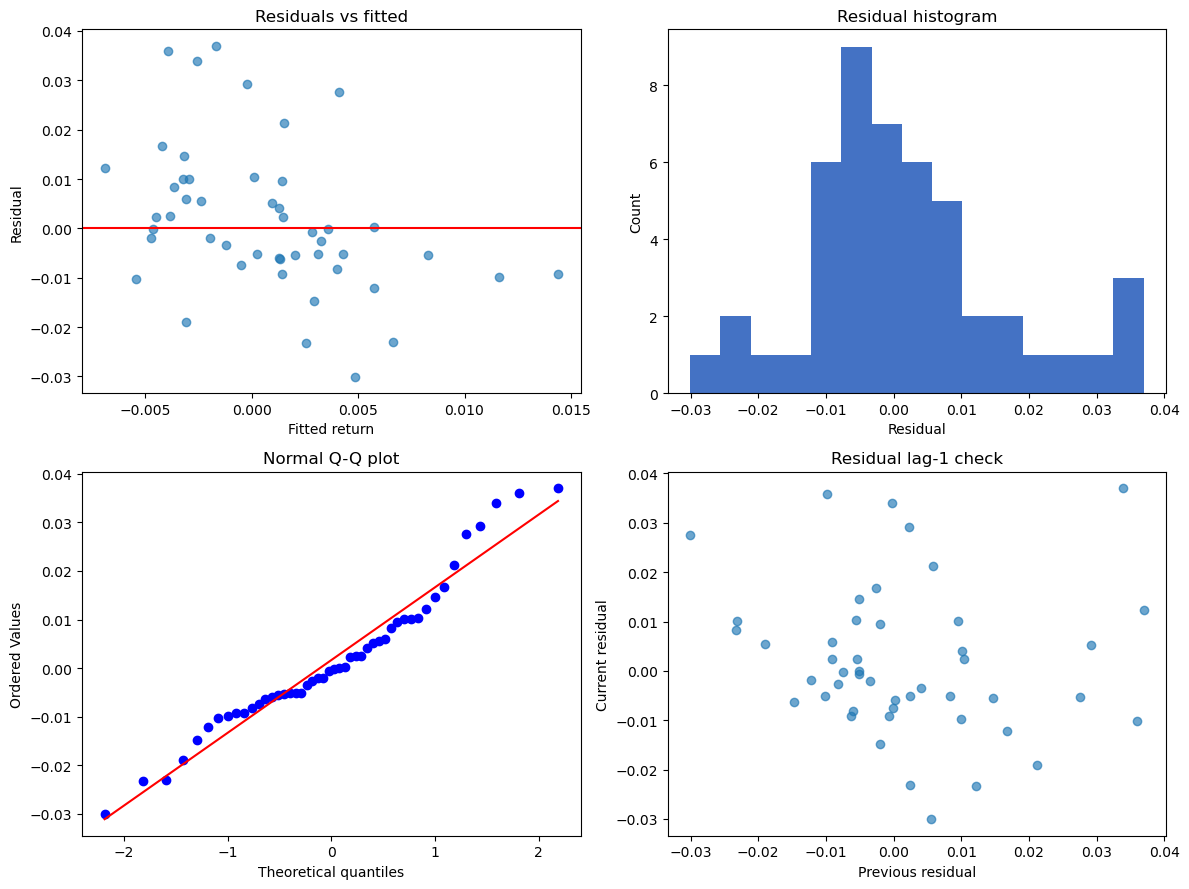

In [2]:
fig,axes=plt.subplots(2,2,figsize=(12,9)); axes[0,0].scatter(pred,residual,alpha=.65); axes[0,0].axhline(0,color='red'); axes[0,0].set(title='Residuals vs fitted',xlabel='Fitted return',ylabel='Residual'); axes[0,1].hist(residual,bins=15,color='#4472C4'); axes[0,1].set(title='Residual histogram',xlabel='Residual',ylabel='Count'); stats.probplot(residual,dist='norm',plot=axes[1,0]); axes[1,0].set_title('Normal Q-Q plot'); ordered=residual.reset_index(drop=True); axes[1,1].scatter(ordered.shift(1),ordered,alpha=.65); axes[1,1].set(title='Residual lag-1 check',xlabel='Previous residual',ylabel='Current residual'); plt.tight_layout(); plt.show()

Residuals show little useful fitted-value structure, but tail departures in the histogram/Q-Q plot weaken normal-error inference. The lag plot is a coarse independence check and cannot rule out volatility clustering. Homoscedasticity is questionable because financial return variance changes across regimes. R² measures explanatory fit, while RMSE expresses typical prediction error in return units; neither makes coefficients causal.

In [3]:
X2=X.copy(); X2['momentum_5_sq']=X2['momentum_5']**2
X2tr,X2te,y2tr,y2te=train_test_split(X2,y,test_size=.2,random_state=5040)
stretch=Pipeline([('scale',StandardScaler()),('linear',LinearRegression())]); stretch.fit(X2tr,y2tr); p2=stretch.predict(X2te)
pd.DataFrame({'baseline':metrics,'with_momentum_squared':{'R2':r2_score(y2te,p2),'RMSE':mean_squared_error(y2te,p2)**.5}})

,baseline,with_momentum_squared
R2,-0.199152,-0.210352
RMSE,0.014825,0.014894


The squared momentum term is still linear regression because coefficients enter linearly even though one input is transformed. I do not strongly trust this model for trading decisions: weak/possibly negative test R² means it may not beat a mean prediction, tails are non-normal, and the random split ignores deployment order. It remains useful as a transparent benchmark; Stage 10b will use a chronological classification pipeline.